# Probability Inequalities and the Law of Large Numbers

## Learning Objectives

By the end of this notebook you will be able to:

1. State and apply **Markov's inequality** to bound tail probabilities using only the mean.
2. State and apply **Chebyshev's inequality** to bound deviations from the mean using only the variance.
3. Prove the **weak law of large numbers** from Chebyshev's inequality.
4. Explain why these "distribution-free" bounds are powerful despite being loose.
5. Appreciate how these results connect the abstract definitions from the previous notebook to the empirical convergence we observed in notebook 01.

## Prerequisites

- [05_random_variables.ipynb](05_random_variables.ipynb) — random variables, expectation $E[X]$, variance $\text{Var}(X)$
- [01_sample_spaces.ipynb](01_sample_spaces.ipynb) — the law of large numbers was stated (without proof) there

In [ ]:
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system(
        "sudo apt-get update -qq && sudo apt-get install -y -qq "
        "libcairo2-dev libpango1.0-dev && pip install -q manim ipython==8.21.0"
    )

_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import apply_style

apply_style()


class Cfg:
    root = Path("../../").resolve()
    gif_dir = root / "media" / "gifs"
    has_latex: bool = (
        shutil.which("latex") is not None or shutil.which("pdflatex") is not None
    )

    def __init__(self):
        self.gif_dir.mkdir(parents=True, exist_ok=True)
        if not self.has_latex:
            print("⚠ LaTeX not found — MathTex will fall back to Text().")

    def apply_manim_config(self):
        from manim import config as mcfg

        mcfg.format = "gif"

    def math_text(self, expr, **kwargs):
        from manim import MathTex, Text

        if self.has_latex:
            return MathTex(expr, **kwargs)
        return Text(expr, **kwargs)

    def save_gifs(self, clean=True):
        local_media = Path("media")
        found = list(local_media.rglob("*.gif")) if local_media.exists() else []
        if not found:
            print("  No new GIFs to save.")
            return
        for gif in found:
            dest = self.gif_dir / gif.name
            shutil.copy2(gif, dest)
            print(f"  ✓ media/gifs/{gif.name}")
        if clean:
            for sub in ("videos", "images", "Tex"):
                d = local_media / sub
                if d.exists():
                    shutil.rmtree(d, ignore_errors=True)
            print("  Cleaned up local temp render files (kept media/jupyter/).")


cfg = Cfg()

---

## 1. The Power of Not Knowing the Distribution

In notebook 05 we defined $E[X]$ and $\text{Var}(X)$. In Module 02 we'll study specific distributions (Binomial, Poisson, Normal, ...) where we can compute exact probabilities like $P(X > 10)$.

But what if we **don't know** which distribution $X$ follows? What if all we know is the mean and variance? Can we still say *anything* useful about the probabilities?

Remarkably, **yes**. Markov's and Chebyshev's inequalities give bounds that hold for *every possible distribution*. They are loose (not tight), but they're guaranteed to work — and that makes them extraordinarily useful in theory.

---

## 2. Markov's Inequality

> **Theorem 6.1 (Markov's inequality).** If $X$ is a **non-negative** random variable ($X \geq 0$) and $a > 0$, then:
>
> $$P(X \geq a) \leq \frac{E[X]}{a}$$

**Proof.** Define an indicator: $I = 1$ if $X \geq a$, else $I = 0$. Since $X \geq 0$, we have $X \geq a \cdot I$ (if $X \geq a$ then $aI = a \leq X$; if $X < a$ then $aI = 0 \leq X$). Taking expectations:

$$E[X] \geq E[a \cdot I] = a \cdot E[I] = a \cdot P(X \geq a)$$

Dividing both sides by $a > 0$: $P(X \geq a) \leq E[X] / a$. $\square$

### What does it say?

"The probability of being far above zero is bounded by the mean divided by how far." If $E[X] = 10$, then $P(X \geq 100) \leq 10/100 = 0.1$. The value can't be large too often, because that would push the mean up.

### Example: exam scores

Students score an average of 70 on an exam (scores $\geq 0$). What fraction can score $\geq 90$?

$$P(X \geq 90) \leq \frac{70}{90} \approx 0.778$$

This bound is **loose** — in practice far fewer than 78% score above 90. But it holds for *any* distribution of scores with mean 70.

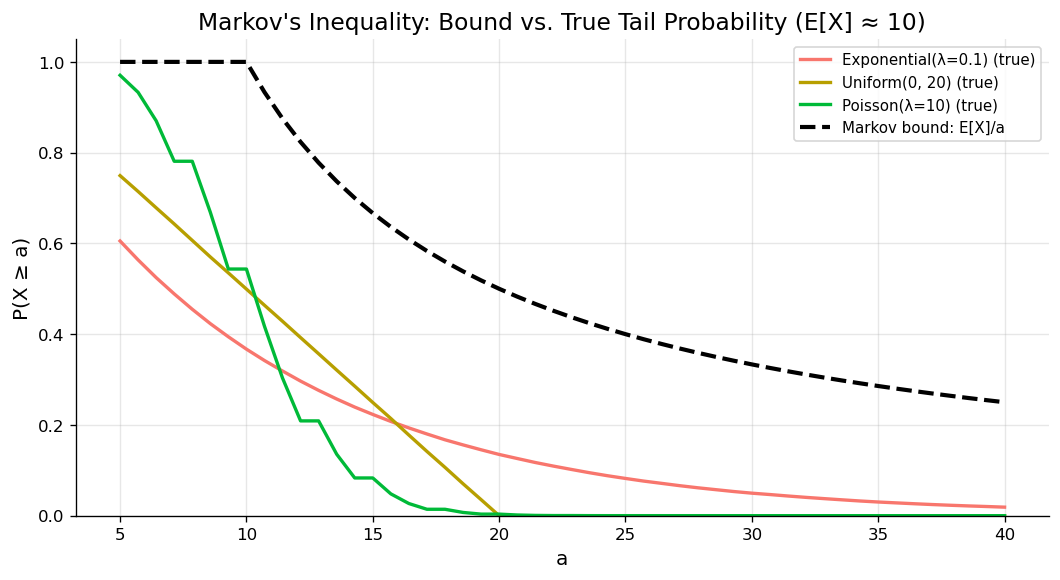

In [2]:
# Markov's inequality: bound vs. truth for different distributions
rng = np.random.default_rng(42)
n = 200_000

# Three very different non-negative distributions, all with mean ≈ 10
distributions = {
    "Exponential(λ=0.1)": rng.exponential(scale=10, size=n),
    "Uniform(0, 20)": rng.uniform(0, 20, size=n),
    "Poisson(λ=10)": rng.poisson(lam=10, size=n).astype(float),
}

a_values = np.linspace(5, 40, 50)

fig, ax = plt.subplots(figsize=(9, 5))

for name, samples in distributions.items():
    mu = samples.mean()
    true_probs = [np.mean(samples >= a) for a in a_values]
    ax.plot(a_values, true_probs, linewidth=2, label=f"{name} (true)")

# Markov bound (same for all since mean ≈ 10)
markov_bound = [min(10 / a, 1.0) for a in a_values]
ax.plot(a_values, markov_bound, "k--", linewidth=2.5, label="Markov bound: E[X]/a")

ax.set_xlabel("a")
ax.set_ylabel("P(X ≥ a)")
ax.set_title("Markov's Inequality: Bound vs. True Tail Probability (E[X] ≈ 10)")
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

The dashed line (Markov bound) is always above all the true curves — it's a valid upper bound for every distribution. But it's often far above the truth. Chebyshev's inequality will give a tighter bound by using the variance.

---

## 3. Chebyshev's Inequality

Chebyshev sharpens Markov by using the variance — it bounds how far $X$ can deviate from its **mean**.

> **Theorem 6.2 (Chebyshev's inequality).** For any random variable $X$ with finite mean $\mu = E[X]$ and finite variance $\sigma^2 = \text{Var}(X)$, for any $k > 0$:
>
> $$P(|X - \mu| \geq k\sigma) \leq \frac{1}{k^2}$$
>
> Equivalently, for any $\epsilon > 0$:
>
> $$P(|X - \mu| \geq \epsilon) \leq \frac{\sigma^2}{\epsilon^2}$$

**Proof.** Apply Markov's inequality to the non-negative random variable $Y = (X - \mu)^2$:

$$P(|X - \mu| \geq \epsilon) = P((X-\mu)^2 \geq \epsilon^2) \leq \frac{E[(X-\mu)^2]}{\epsilon^2} = \frac{\sigma^2}{\epsilon^2} \quad \square$$

### What does it say?

"The probability of being more than $k$ standard deviations from the mean is at most $1/k^2$." Concretely:

| $k$ (SDs from mean) | Chebyshev bound $P(|X - \mu| \geq k\sigma) \leq$ |
|---|---|
| 1 | 1.000 (trivial) |
| 2 | 0.250 |
| 3 | 0.111 |
| 4 | 0.0625 |
| 5 | 0.040 |
| 10 | 0.010 |

For a Normal distribution, $P(|X - \mu| \geq 2\sigma) \approx 0.046$ — much smaller than Chebyshev's bound of 0.25. The bound is loose but **universal**.

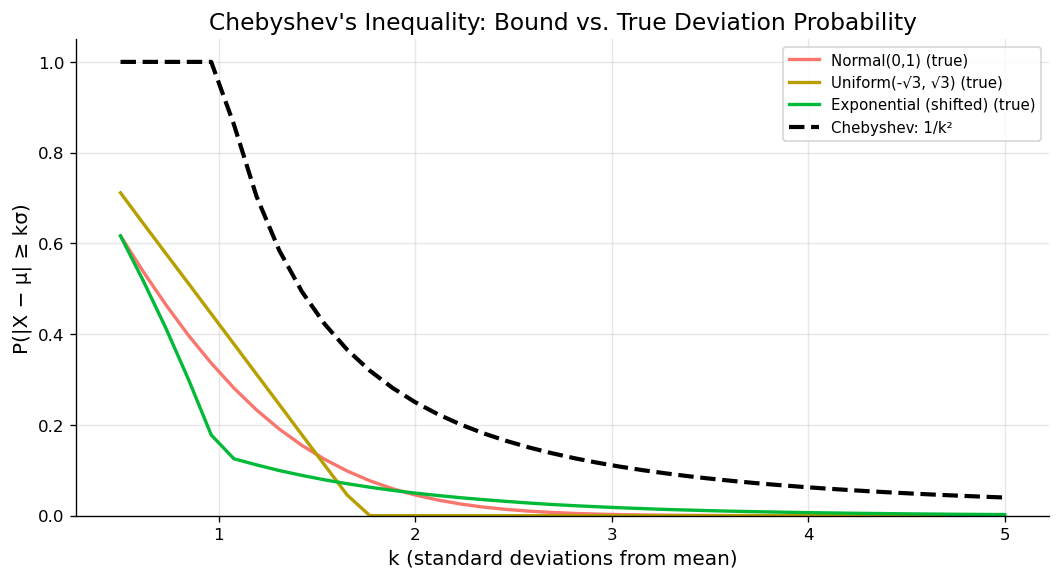

In [3]:
# Chebyshev vs. truth for different distributions
rng = np.random.default_rng(42)
n = 500_000

# All with mean ≈ 0, variance ≈ 1 (standardised)
dists = {
    "Normal(0,1)": rng.normal(0, 1, n),
    "Uniform(-√3, √3)": rng.uniform(-np.sqrt(3), np.sqrt(3), n),
    "Exponential (shifted)": rng.exponential(1, n) - 1,  # mean 0, var 1
}

k_values = np.linspace(0.5, 5, 40)

fig, ax = plt.subplots(figsize=(9, 5))

for name, samples in dists.items():
    mu = samples.mean()
    sigma = samples.std()
    true_probs = [np.mean(np.abs(samples - mu) >= k * sigma) for k in k_values]
    ax.plot(k_values, true_probs, linewidth=2, label=f"{name} (true)")

# Chebyshev bound
cheb_bound = [min(1 / k**2, 1.0) for k in k_values]
ax.plot(k_values, cheb_bound, "k--", linewidth=2.5, label="Chebyshev: 1/k²")

ax.set_xlabel("k (standard deviations from mean)")
ax.set_ylabel("P(|X − μ| ≥ kσ)")
ax.set_title("Chebyshev's Inequality: Bound vs. True Deviation Probability")
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

The Chebyshev bound (dashed) is always above every curve — it works for any distribution. But the true probabilities fall off much faster. For the Normal distribution especially, the bound is very conservative. Its value is theoretical: it works when we **don't know** the distribution.

### Visualising Chebyshev

The animation below shows Chebyshev's inequality in action: as we widen the band around the mean (increasing $k$), the bound on the probability in the tails shrinks as $1/k^2$.

In [4]:
from manim import *

cfg.apply_manim_config()
math_text = cfg.math_text

from amstats.manim_utils import C, COLORS

Manim Community v0.18.1

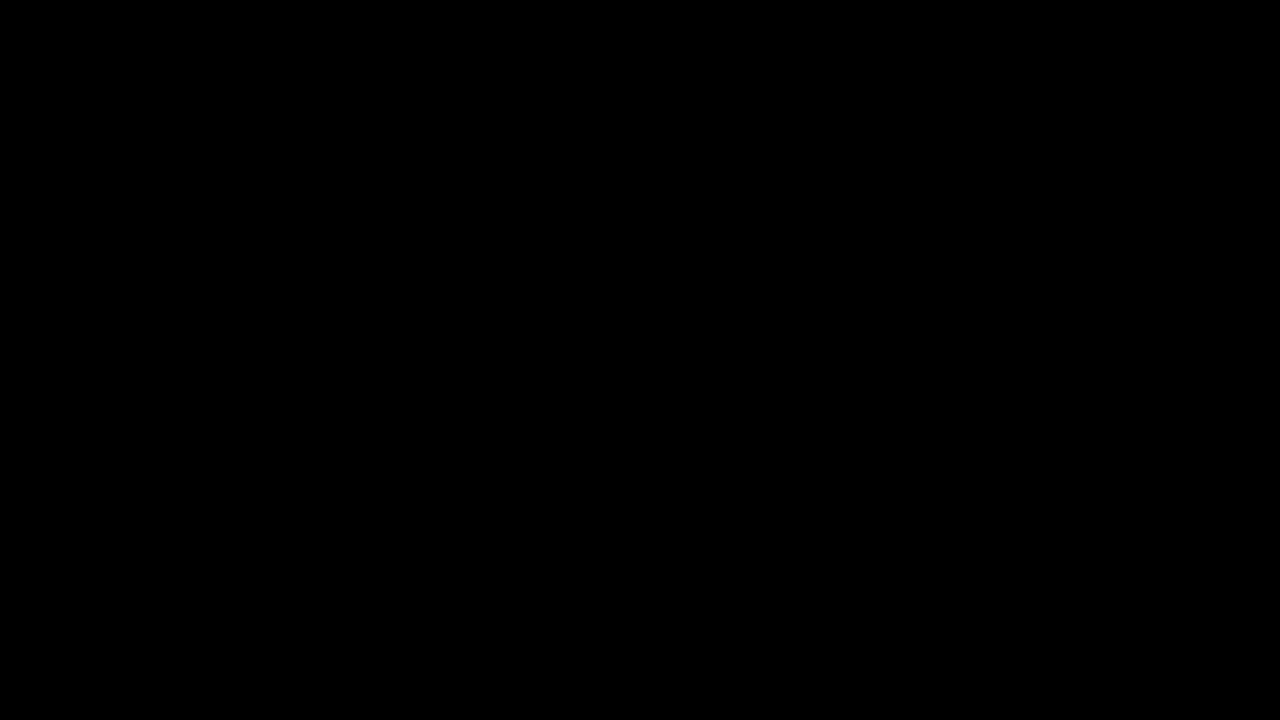

In [ ]:
%%manim -qm -v WARNING ChebyshevAnimation


class ChebyshevAnimation(Scene):
    """Animate Chebyshev's inequality: widening band shrinks tail bound."""

    def construct(self):
        title = Text("Chebyshev's Inequality", font_size=30).to_edge(UP)
        self.play(Write(title))

        # Draw a generic bell-ish curve (not necessarily normal)
        axes = Axes(
            x_range=[-4, 4, 1],
            y_range=[0, 0.5, 0.1],
            x_length=10,
            y_length=4,
            axis_config={"include_numbers": True, "font_size": 18},
        ).shift(DOWN * 0.5)

        # Generic symmetric distribution (sum of uniforms — triangular-ish)
        def pdf(x):
            return 0.4 * np.exp(-0.5 * x**2)  # Gaussian-looking for illustration

        curve = axes.plot(pdf, x_range=[-4, 4], color=C.PERIWINKLE, stroke_width=3)
        mu_line = axes.get_vertical_line(
            axes.c2p(0, pdf(0)), color=C.GOLD, line_func=DashedLine
        )
        mu_label = math_text(r"\mu", font_size=24, color=C.GOLD).next_to(
            mu_line, UP, buff=0.1
        )

        self.play(
            Create(axes), Create(curve), Create(mu_line), Write(mu_label), run_time=1.2
        )

        # Animate k = 1, 2, 3, 4
        prev_region = None
        prev_text = None

        for k in [1, 2, 3, 4]:
            # Shaded tails beyond ±kσ
            left_tail = axes.get_area(
                curve, x_range=[-4, -k], color=C.SALMON, opacity=0.4
            )
            right_tail = axes.get_area(
                curve, x_range=[k, 4], color=C.SALMON, opacity=0.4
            )
            tails = VGroup(left_tail, right_tail)

            # Bound text
            bound_val = 1 / k**2
            info = math_text(
                rf"k = {k}: \quad P(|X - \mu| \geq {k}\sigma) \leq 1/{k}^2 = {bound_val:.3f}",
                font_size=22,
                color=C.SALMON,
            ).to_edge(DOWN, buff=0.4)

            # Vertical lines at ±kσ
            left_v = DashedLine(
                axes.c2p(-k, 0),
                axes.c2p(-k, pdf(-k)),
                color=C.EMERALD,
                stroke_width=2,
                dash_length=0.06,
            )
            right_v = DashedLine(
                axes.c2p(k, 0),
                axes.c2p(k, pdf(k)),
                color=C.EMERALD,
                stroke_width=2,
                dash_length=0.06,
            )

            if prev_region is None:
                self.play(
                    FadeIn(tails),
                    Write(info),
                    Create(left_v),
                    Create(right_v),
                    run_time=1,
                )
            else:
                self.play(
                    Transform(prev_region, tails),
                    Transform(prev_text, info),
                    Create(left_v),
                    Create(right_v),
                    run_time=0.8,
                )

            if prev_region is None:
                prev_region = tails
                prev_text = info

            self.wait(1)

        self.wait(1)

As $k$ increases (the dashed lines move outward), the shaded tail area shrinks — and Chebyshev guarantees it's at most $1/k^2$. By $k = 4$, the bound is only 6.25%, regardless of the distribution's shape.

---

## 4. The Weak Law of Large Numbers — Proved!

In notebook 01 we *stated* the law of large numbers and showed it empirically with coin flips. Now we can **prove** it using Chebyshev's inequality.

> **Theorem 6.3 (Weak law of large numbers).** Let $X_1, X_2, \dots, X_n$ be independent random variables, each with the same mean $\mu$ and variance $\sigma^2$. Let $\bar{X}_n = \frac{1}{n}\sum_{i=1}^n X_i$. Then for any $\epsilon > 0$:
>
> $$P(|\bar{X}_n - \mu| \geq \epsilon) \xrightarrow{n \to \infty} 0$$

**Proof.** We compute the mean and variance of $\bar{X}_n$:

1. **Mean:** By linearity of expectation:
   $$E[\bar{X}_n] = E\!\left[\frac{1}{n}\sum_{i=1}^n X_i\right] = \frac{1}{n}\sum_{i=1}^n E[X_i] = \frac{1}{n} \cdot n\mu = \mu$$

2. **Variance:** Since the $X_i$ are independent, $\text{Var}(\sum X_i) = \sum \text{Var}(X_i)$, so:
   $$\text{Var}(\bar{X}_n) = \text{Var}\!\left(\frac{1}{n}\sum X_i\right) = \frac{1}{n^2} \cdot n\sigma^2 = \frac{\sigma^2}{n}$$

3. **Apply Chebyshev:** 
   $$P(|\bar{X}_n - \mu| \geq \epsilon) \leq \frac{\text{Var}(\bar{X}_n)}{\epsilon^2} = \frac{\sigma^2}{n\epsilon^2}$$

As $n \to \infty$, the right side $\to 0$. $\square$

**This is why the coin flip relative frequencies converge to 0.5.** The variance of the sample mean shrinks like $1/n$, so the probability of being far from $\mu$ vanishes.

Let's visualise this: the Chebyshev bound $\sigma^2 / (n\epsilon^2)$ versus the true probability of deviation, as $n$ grows.

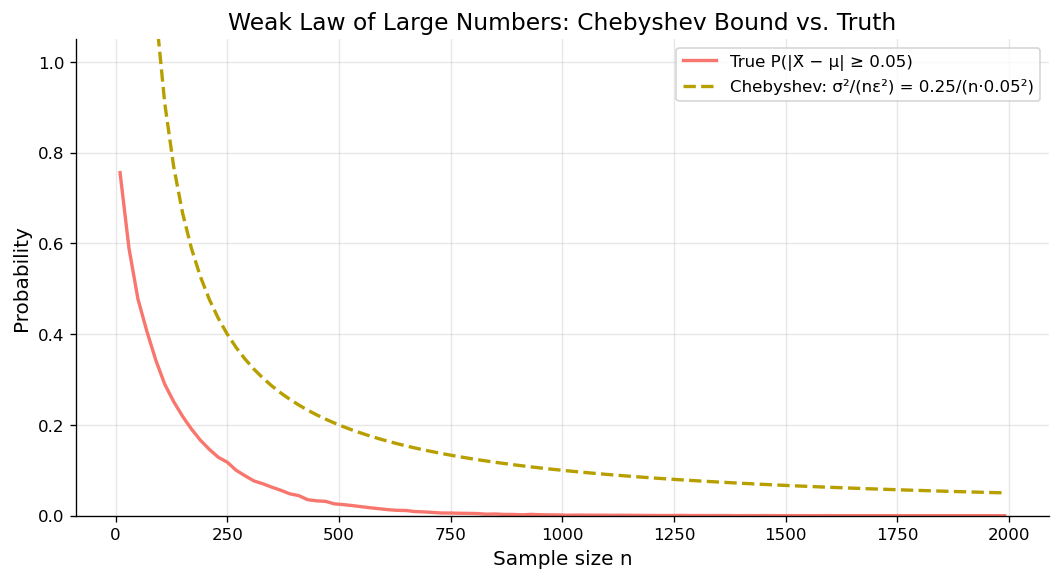

In [ ]:
# LLN: Chebyshev bound vs. truth as n grows
rng = np.random.default_rng(42)

# Fair coin: X_i ∈ {0, 1}, μ = 0.5, σ² = 0.25
mu = 0.5
sigma2 = 0.25
epsilon = 0.05  # P(|X̄ - 0.5| ≥ 0.05)

n_values = np.arange(10, 2001, 20)
n_sims = 20_000

true_probs = []
for n in n_values:
    # Simulate n_sims sample means of size n
    means = rng.binomial(n, 0.5, size=n_sims) / n
    true_probs.append(np.mean(np.abs(means - mu) >= epsilon))

chebyshev_bound = sigma2 / (n_values * epsilon**2)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_values, true_probs, linewidth=2, label=f"True P(|X̄ − μ| ≥ {epsilon})")
ax.plot(
    n_values,
    chebyshev_bound,
    "--",
    linewidth=2,
    label=f"Chebyshev: σ²/(nε²) = {sigma2}/(n·{epsilon}²)",
)
ax.set_xlabel("Sample size n")
ax.set_ylabel("Probability")
ax.set_title("Weak Law of Large Numbers: Chebyshev Bound vs. Truth")
ax.legend(fontsize=10)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

Both the true probability and the Chebyshev bound go to zero as $n$ grows — but the bound is much more conservative. The true convergence is faster than Chebyshev guarantees. Nevertheless, the bound is enough to prove the law of large numbers, and that's what matters.

---

## 5. Closing the Loop

Let's reflect on what we've accomplished across Module 01:

1. **Notebook 01:** We *observed* that relative frequencies converge to the true probability — the law of large numbers as an empirical fact.
2. **Notebook 05:** We defined expectation and variance — the tools needed to *state* the law precisely.
3. **This notebook:** We *proved* it using Chebyshev's inequality, which itself follows from Markov's inequality.

The chain is: **Axioms → Expectation → Markov → Chebyshev → LLN**. Everything flows from the three Kolmogorov axioms.

This is a recurring pattern in the course: observe something empirically (simulation), then build the theory to explain *why* it works.

---

## Exercises

**Exercise 6.1 (Markov).** A factory produces light bulbs with an average lifetime of 1000 hours ($X \geq 0$). Using only Markov's inequality, bound $P(X \geq 3000)$.

**Exercise 6.2 (Chebyshev).** A process has mean $\mu = 50$ and standard deviation $\sigma = 5$. Bound $P(|X - 50| \geq 15)$ using Chebyshev. Compare with the exact answer if $X \sim \text{Normal}(50, 5^2)$.

**Exercise 6.3 (LLN sample size).** You want to estimate the mean of a distribution with $\sigma^2 = 4$. Using Chebyshev's inequality, how large must $n$ be to guarantee $P(|\bar{X}_n - \mu| \geq 0.1) \leq 0.05$?

**Exercise 6.4 (Tightness).** Construct a random variable where Chebyshev's bound is (approximately) **tight** — i.e., $P(|X - \mu| \geq k\sigma)$ is close to $1/k^2$. (*Hint:* consider a three-point distribution.)

**Exercise 6.5 (Simulation).** For $X \sim \text{Uniform}(0, 1)$, compute the exact $P(|X - 0.5| \geq \epsilon)$ for $\epsilon = 0.1, 0.2, 0.3, 0.4, 0.5$ and compare with the Chebyshev bound. Plot both.

**Exercise 6.6 (Challenge).** Prove the **one-sided Chebyshev inequality** (Cantelli's inequality): for any $t > 0$,
$$P(X - \mu \geq t) \leq \frac{\sigma^2}{\sigma^2 + t^2}$$
(*Hint:* apply Markov to $(X - \mu + c)^2$ and optimise over $c$.)

---

## Key Takeaways

1. **Markov's inequality** bounds $P(X \geq a) \leq E[X]/a$ for non-negative $X$ — uses only the mean.
2. **Chebyshev's inequality** bounds $P(|X - \mu| \geq k\sigma) \leq 1/k^2$ — uses mean and variance.
3. Both are **distribution-free**: they hold for any distribution. They're loose but universal.
4. Chebyshev directly proves the **weak law of large numbers**: $\bar{X}_n \to \mu$ in probability, because $\text{Var}(\bar{X}_n) = \sigma^2/n \to 0$.
5. This closes the loop from notebook 01: the empirical convergence we observed is a **theorem**, not just a pattern.

**This completes Module 01: Probability Basics.**

**Next:** [Module 02 — Distributions](../02_distributions/01_discrete_distributions.ipynb) — Named probability distributions and their properties.

In [7]:
cfg.save_gifs(clean=True)

  ✓ media/gifs/ChebyshevAnimation@2026-03-19@23-48-58.gif
  ✓ media/gifs/CoinFlipConvergence@2026-03-19@12-05-35.gif
  ✓ media/gifs/CoinFlipConvergence@2026-03-19@12-10-14.gif
  ✓ media/gifs/CoinFlipConvergence@2026-03-19@13-42-51.gif
  ✓ media/gifs/ConditionalProbVenn@2026-03-19@13-48-05.gif
  ✓ media/gifs/DiceHistogram@2026-03-19@13-43-26.gif
  ✓ media/gifs/ExpectedValueBalance@2026-03-19@14-01-49.gif
  ✓ media/gifs/PascalTriangle@2026-03-19@13-44-25.gif
  ✓ media/gifs/TotalProbabilityPartition@2026-03-19@13-50-32.gif
  ✓ media/gifs/TreeDiagram@2026-03-19@13-44-07.gif
  ✓ media/gifs/ChebyshevAnimation_ManimCE_v0.18.1.gif
  Cleaned up local temp render files (kept media/jupyter/).
